# EDA Step 7: 피처 엔지니어링 탐색 (Feature Engineering Exploration)

**목표**: 파생 변수를 생성하고, 피처 중요도를 평가하여 모델링 전략을 수립합니다.

**분석 항목**:
- 파생 변수: family_size, is_child, log_fare, fare_per_person, age_group, deck_known
- RF feature_importances_ + permutation importance
- FN 분석 (놓친 생존자 프로파일)
- 최종 피처 추천표
- Recall 개선 전략

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

df = sns.load_dataset('titanic')
print(f'Data loaded: {df.shape}')

Data loaded: (891, 15)


## 7.1 파생 변수 생성

In [2]:
# 결측 처리 (Step 6 전략 적용)
# age: pclass+sex group median + dummy
df['age_missing'] = df['age'].isnull().astype(int)
medians = df.groupby(['pclass', 'sex'])['age'].median()
for (pc, sx), med in medians.items():
    mask = (df['pclass'] == pc) & (df['sex'] == sx) & df['age'].isnull()
    df.loc[mask, 'age'] = med
df['age'] = df['age'].fillna(df['age'].median())

# embarked: mode
df['embarked'] = df['embarked'].fillna('S')

# deck_known
df['deck_known'] = df['deck'].notna().astype(int)

# 파생 변수
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['is_child'] = (df['age'] <= 12).astype(int)
df['is_senior'] = (df['age'] >= 60).astype(int)
df['log_fare'] = np.log1p(df['fare'])
df['fare_per_person'] = df['fare'] / df['family_size']
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 80], labels=[0, 1, 2, 3, 4]).astype(int)
df['family_group'] = pd.cut(df['family_size'], bins=[0, 1, 4, 11], labels=[0, 1, 2]).astype(int)
df['sex_encoded'] = (df['sex'] == 'male').astype(int)
df['pclass_sex'] = df['pclass'].astype(str) + '_' + df['sex']

# who 인코딩
who_map = {'man': 0, 'woman': 1, 'child': 2}
df['who_encoded'] = df['who'].map(who_map)

# embarked 인코딩
embarked_map = {'S': 0, 'C': 1, 'Q': 2}
df['embarked_encoded'] = df['embarked'].map(embarked_map)

print('Derived features created!')
print(f'Total columns: {len(df.columns)}')

Derived features created!
Total columns: 29


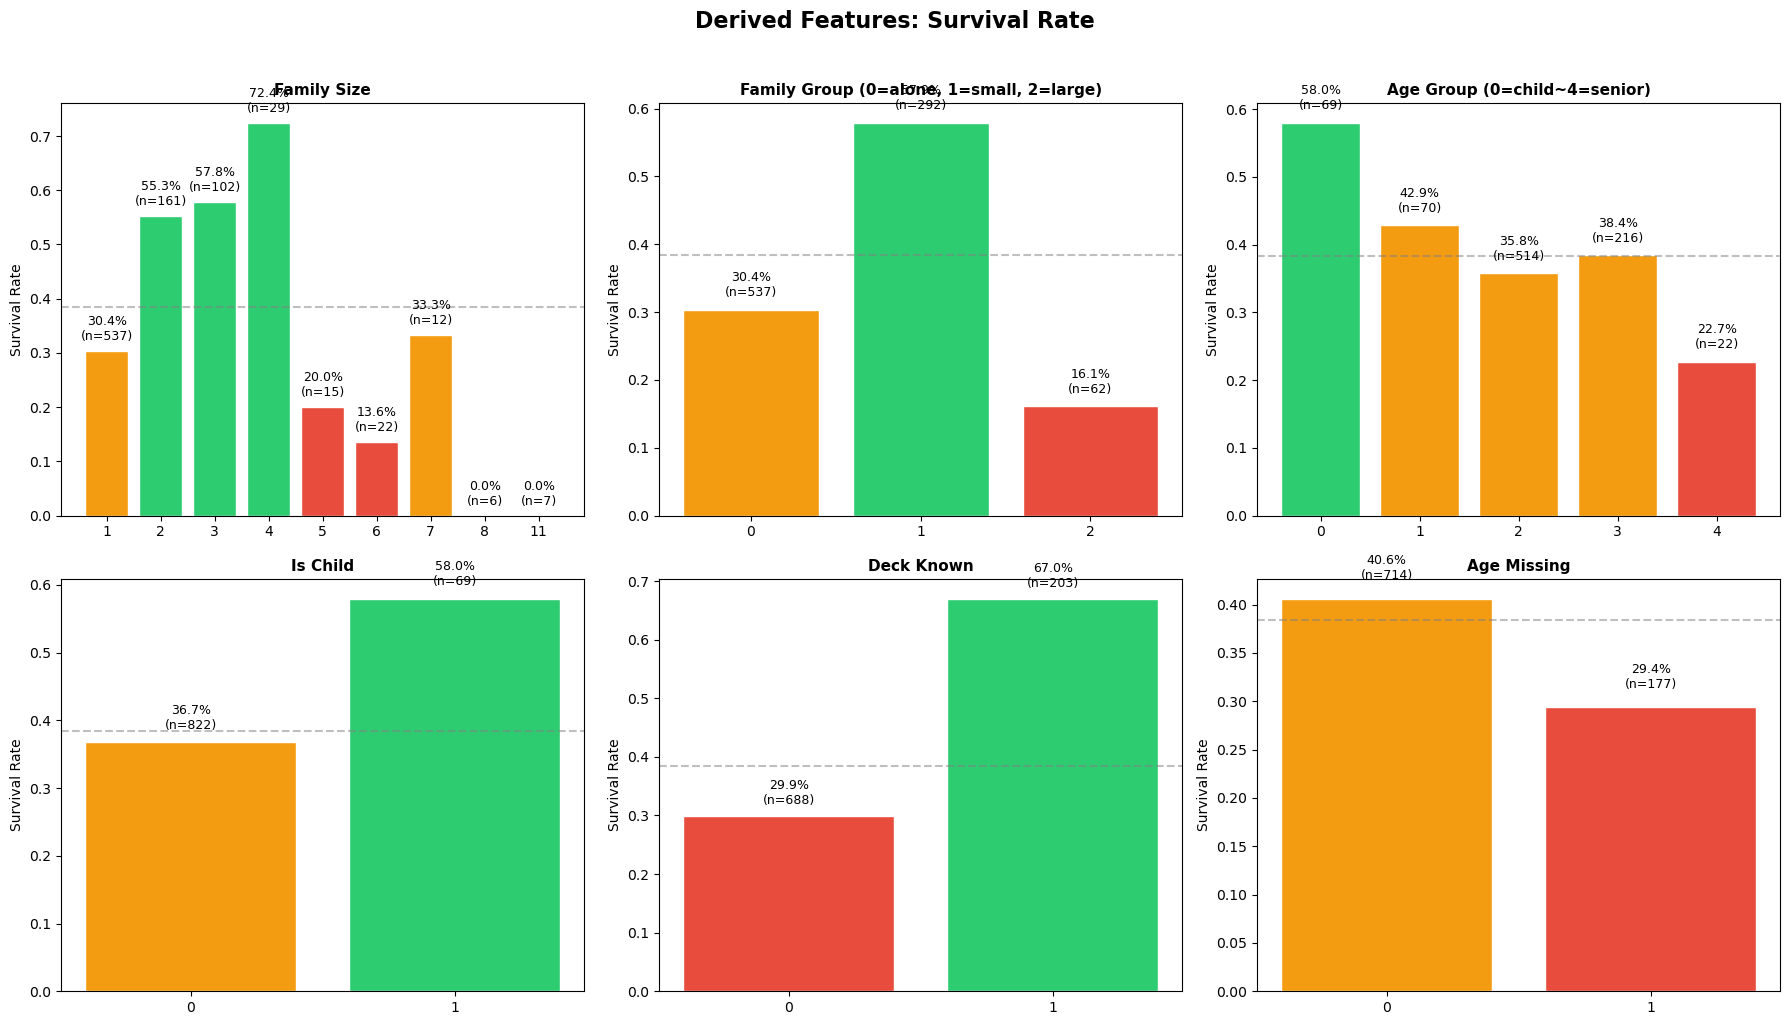

In [3]:
# 파생 변수 생존율 분석
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

derived_vars = [
    ('family_size', 'Family Size'),
    ('family_group', 'Family Group (0=alone, 1=small, 2=large)'),
    ('age_group', 'Age Group (0=child~4=senior)'),
    ('is_child', 'Is Child'),
    ('deck_known', 'Deck Known'),
    ('age_missing', 'Age Missing'),
]

for idx, (var, title) in enumerate(derived_vars):
    ax = axes[idx]
    surv = df.groupby(var)['survived'].agg(['mean', 'count'])
    colors_d = ['#2ecc71' if r > 0.5 else '#f39c12' if r > 0.3 else '#e74c3c' for r in surv['mean']]
    bars = ax.bar(range(len(surv)), surv['mean'].values, color=colors_d, edgecolor='white')
    ax.set_xticks(range(len(surv)))
    ax.set_xticklabels([str(x) for x in surv.index])
    for bar, (rate, count) in zip(bars, surv.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}\n(n={int(count)})', ha='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Survival Rate')
    ax.axhline(y=df['survived'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Derived Features: Survival Rate', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step7_derived_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.2 피처 중요도 (RandomForest)

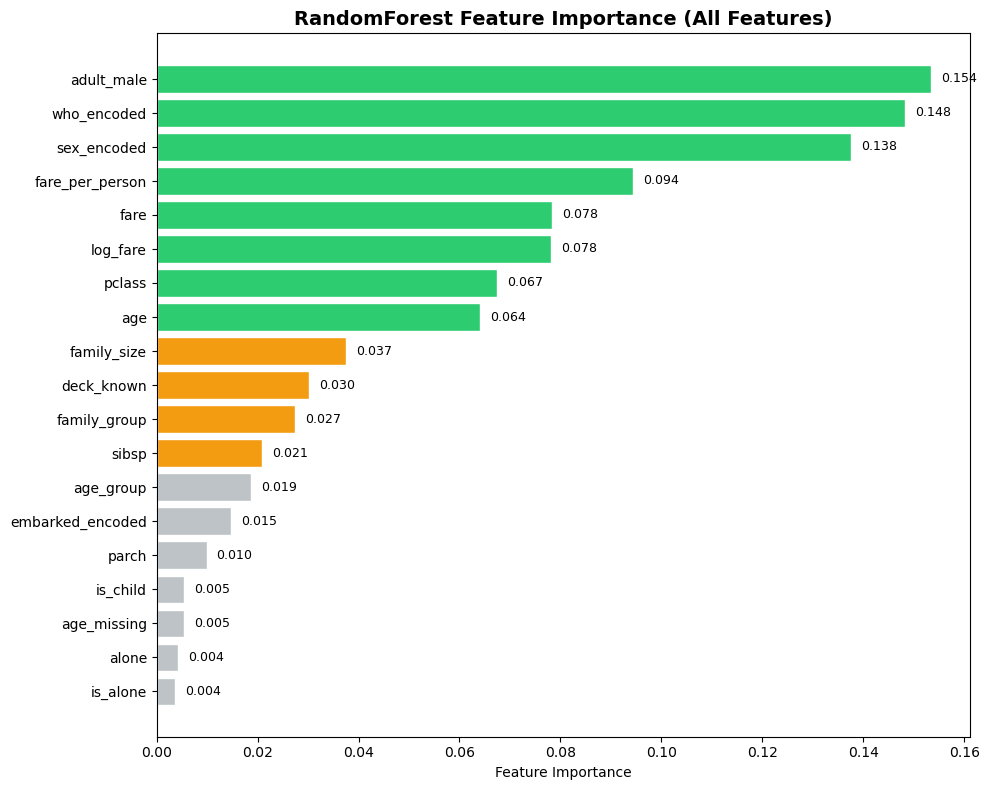


Top 10 Features:
  adult_male          : 0.1535
  who_encoded         : 0.1484
  sex_encoded         : 0.1376
  fare_per_person     : 0.0944
  fare                : 0.0783
  log_fare            : 0.0781
  pclass              : 0.0675
  age                 : 0.0640
  family_size         : 0.0375
  deck_known          : 0.0302


In [4]:
# 전체 피처셋 구성
feature_cols = [
    'pclass', 'age', 'sibsp', 'parch', 'fare', 'log_fare',
    'sex_encoded', 'embarked_encoded', 'who_encoded',
    'adult_male', 'alone', 'deck_known', 'age_missing',
    'family_size', 'is_alone', 'is_child', 'fare_per_person',
    'age_group', 'family_group'
]

X = df[feature_cols].copy()
X['adult_male'] = X['adult_male'].astype(int)
X['alone'] = X['alone'].astype(int)
y = df['survived']

# 전체 데이터로 학습
rf = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=SEED)
rf.fit(X, y)

# Feature Importance
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ['#2ecc71' if v > 0.05 else '#f39c12' if v > 0.02 else '#bdc3c7' for v in importances['Importance']]
ax.barh(importances['Feature'], importances['Importance'], color=colors_imp, edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('RandomForest Feature Importance (All Features)', fontsize=14, fontweight='bold')

for i, (feat, imp) in enumerate(zip(importances['Feature'], importances['Importance'])):
    ax.text(imp + 0.002, i, f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/eda_step7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
top10 = importances.tail(10).iloc[::-1]
for _, row in top10.iterrows():
    print(f'  {row["Feature"]:20s}: {row["Importance"]:.4f}')

## 7.3 Permutation Importance

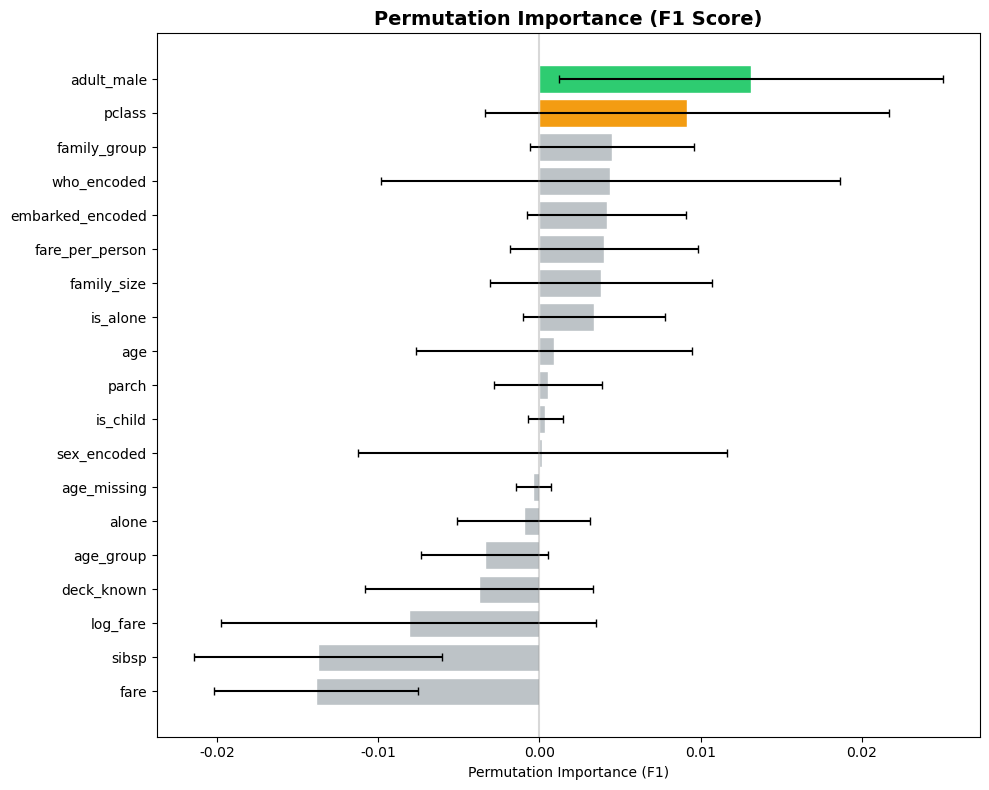

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
rf2 = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=SEED)
rf2.fit(X_train, y_train)

perm_imp = permutation_importance(rf2, X_test, y_test, n_repeats=10, random_state=SEED, scoring='f1')

perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Perm Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Perm Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_perm = ['#2ecc71' if v > 0.01 else '#f39c12' if v > 0.005 else '#bdc3c7' for v in perm_df['Perm Importance']]
ax.barh(perm_df['Feature'], perm_df['Perm Importance'], xerr=perm_df['Std'],
        color=colors_perm, edgecolor='white', capsize=3)
ax.set_xlabel('Permutation Importance (F1)')
ax.set_title('Permutation Importance (F1 Score)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_step7_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.4 FN 분석 (놓친 생존자 프로파일)

In [6]:
# 현재 모델로 FN 분석
y_pred = rf2.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')

# FN 승객 프로파일
test_df = df.iloc[X_test.index].copy()
test_df['predicted'] = y_pred
fn_passengers = test_df[(test_df['survived'] == 1) & (test_df['predicted'] == 0)]

print(f'\n=== False Negative Passengers ({len(fn_passengers)} survivors missed) ===')
print(f'\nSex distribution:')
print(fn_passengers['sex'].value_counts().to_string())
print(f'\nPclass distribution:')
print(fn_passengers['pclass'].value_counts().to_string())
print(f'\nWho distribution:')
print(fn_passengers['who'].value_counts().to_string())
print(f'\nAge stats:')
print(f'  Mean: {fn_passengers["age"].mean():.1f}')
print(f'  Median: {fn_passengers["age"].median():.1f}')
print(f'\nFamily size distribution:')
print(fn_passengers['family_size'].value_counts().sort_index().to_string())

# FN vs TP 비교
tp_passengers = test_df[(test_df['survived'] == 1) & (test_df['predicted'] == 1)]
fn_male_pct = f'{fn_passengers["sex"].eq("male").mean():.1%}'
tp_male_pct = f'{tp_passengers["sex"].eq("male").mean():.1%}'
fn_p3_pct = f'{(fn_passengers["pclass"]==3).mean():.1%}'
tp_p3_pct = f'{(tp_passengers["pclass"]==3).mean():.1%}'
fn_alone_pct = f'{fn_passengers["is_alone"].mean():.1%}'
tp_alone_pct = f'{tp_passengers["is_alone"].mean():.1%}'

print(f'\n=== FN vs TP Comparison ===')
print(f'{"Metric":<20} {"FN (missed)":<15} {"TP (caught)":<15}')
print('-' * 50)
print(f'{"Male %":<20} {fn_male_pct:<15} {tp_male_pct:<15}')
print(f'{"Pclass 3 %":<20} {fn_p3_pct:<15} {tp_p3_pct:<15}')
print(f'{"Mean age":<20} {fn_passengers["age"].mean():<15.1f} {tp_passengers["age"].mean():<15.1f}')
print(f'{"Mean fare":<20} {fn_passengers["fare"].mean():<15.1f} {tp_passengers["fare"].mean():<15.1f}')
print(f'{"Alone %":<20} {fn_alone_pct:<15} {tp_alone_pct:<15}')

Confusion Matrix: TN=141, FP=24, FN=31, TP=72
F1: 0.7236
Recall: 0.6990
Precision: 0.7500

=== False Negative Passengers (31 survivors missed) ===

Sex distribution:
sex
male      20
female    11

Pclass distribution:
pclass
3    21
1     8
2     2

Who distribution:
who
man      19
woman     9
child     3

Age stats:
  Mean: 29.0
  Median: 27.0

Family size distribution:
family_size
1    15
2    11
3     4
7     1

=== FN vs TP Comparison ===
Metric               FN (missed)     TP (caught)    
--------------------------------------------------
Male %               64.5%           18.1%          
Pclass 3 %           67.7%           16.7%          
Mean age             29.0            28.3           
Mean fare            37.1            55.3           
Alone %              48.4%           40.3%          


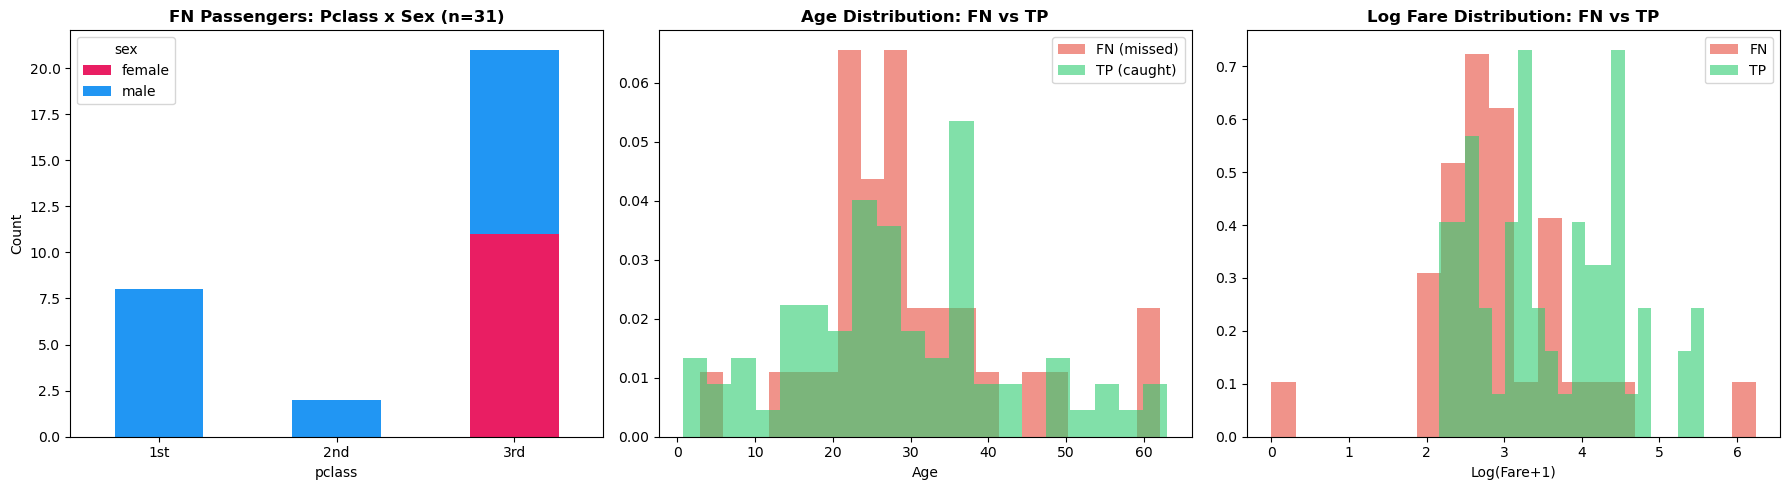

In [7]:
# FN 프로파일 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FN vs TP: pclass x sex
ax = axes[0]
fn_ct = pd.crosstab(fn_passengers['pclass'], fn_passengers['sex'])
fn_ct.plot(kind='bar', ax=ax, color=['#e91e63', '#2196f3'], stacked=True)
ax.set_title(f'FN Passengers: Pclass x Sex (n={len(fn_passengers)})', fontsize=12, fontweight='bold')
ax.set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
ax.set_ylabel('Count')

# FN age distribution
ax = axes[1]
ax.hist(fn_passengers['age'], bins=20, alpha=0.6, color='#e74c3c', label='FN (missed)', density=True)
ax.hist(tp_passengers['age'], bins=20, alpha=0.6, color='#2ecc71', label='TP (caught)', density=True)
ax.set_title('Age Distribution: FN vs TP', fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlabel('Age')

# FN fare distribution
ax = axes[2]
ax.hist(fn_passengers['log_fare'], bins=20, alpha=0.6, color='#e74c3c', label='FN', density=True)
ax.hist(tp_passengers['log_fare'], bins=20, alpha=0.6, color='#2ecc71', label='TP', density=True)
ax.set_title('Log Fare Distribution: FN vs TP', fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlabel('Log(Fare+1)')

plt.tight_layout()
plt.savefig('../reports/eda_step7_fn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.5 Recall 개선 전략 시뮬레이션

In [8]:
# class_weight 효과 + threshold 조정
results = []

# 1. Default
rf_default = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=SEED)
rf_default.fit(X_train, y_train)
y_pred_def = rf_default.predict(X_test)
results.append(('Default', f1_score(y_test, y_pred_def), precision_score(y_test, y_pred_def), recall_score(y_test, y_pred_def)))

# 2. class_weight='balanced'
rf_bal = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=SEED, class_weight='balanced')
rf_bal.fit(X_train, y_train)
y_pred_bal = rf_bal.predict(X_test)
results.append(('Balanced Weight', f1_score(y_test, y_pred_bal), precision_score(y_test, y_pred_bal), recall_score(y_test, y_pred_bal)))

# 3. Threshold adjustment (0.4)
y_proba = rf_default.predict_proba(X_test)[:, 1]
y_pred_t04 = (y_proba >= 0.4).astype(int)
results.append(('Threshold=0.4', f1_score(y_test, y_pred_t04), precision_score(y_test, y_pred_t04), recall_score(y_test, y_pred_t04)))

# 4. Threshold=0.35
y_pred_t035 = (y_proba >= 0.35).astype(int)
results.append(('Threshold=0.35', f1_score(y_test, y_pred_t035), precision_score(y_test, y_pred_t035), recall_score(y_test, y_pred_t035)))

# 5. Balanced + Threshold=0.4
y_proba_bal = rf_bal.predict_proba(X_test)[:, 1]
y_pred_bt04 = (y_proba_bal >= 0.4).astype(int)
results.append(('Balanced+T=0.4', f1_score(y_test, y_pred_bt04), precision_score(y_test, y_pred_bt04), recall_score(y_test, y_pred_bt04)))

recall_df = pd.DataFrame(results, columns=['Strategy', 'F1', 'Precision', 'Recall'])
recall_df = recall_df.sort_values('F1', ascending=False)
print('Recall Improvement Strategies')
print('=' * 60)
print(recall_df.to_string(index=False, float_format='{:.4f}'.format))

Recall Improvement Strategies
       Strategy     F1  Precision  Recall
 Threshold=0.35 0.7753     0.7097  0.8544
 Balanced+T=0.4 0.7719     0.7040  0.8544
  Threshold=0.4 0.7535     0.7232  0.7864
Balanced Weight 0.7488     0.7315  0.7670
        Default 0.7236     0.7500  0.6990


## 7.6 최종 피처 추천표

In [9]:
# 최종 피처 추천
recommendations = pd.DataFrame([
    {'Feature': 'sex_encoded', 'Type': 'Original', 'Priority': 'Essential', 'Note': 'Most important predictor'},
    {'Feature': 'pclass', 'Type': 'Original', 'Priority': 'Essential', 'Note': 'Strong survival signal'},
    {'Feature': 'fare / log_fare', 'Type': 'Transform', 'Priority': 'Essential', 'Note': 'Log transform reduces skew'},
    {'Feature': 'age', 'Type': 'Imputed', 'Priority': 'Essential', 'Note': 'pclass+sex group median'},
    {'Feature': 'family_size', 'Type': 'Derived', 'Priority': 'High', 'Note': 'sibsp+parch+1, optimal 2-4'},
    {'Feature': 'who_encoded', 'Type': 'Original', 'Priority': 'High', 'Note': 'man/woman/child - strong signal'},
    {'Feature': 'adult_male', 'Type': 'Original', 'Priority': 'High', 'Note': 'Correlated with sex but adds value'},
    {'Feature': 'deck_known', 'Type': 'Derived', 'Priority': 'Medium', 'Note': 'Binary from deck missing'},
    {'Feature': 'age_missing', 'Type': 'Derived', 'Priority': 'Medium', 'Note': 'Dummy for age imputation'},
    {'Feature': 'embarked_encoded', 'Type': 'Original', 'Priority': 'Medium', 'Note': 'C > Q > S survival'},
    {'Feature': 'is_child', 'Type': 'Derived', 'Priority': 'Medium', 'Note': 'age <= 12'},
    {'Feature': 'fare_per_person', 'Type': 'Derived', 'Priority': 'Low', 'Note': 'fare / family_size'},
    {'Feature': 'alone', 'Type': 'Original', 'Priority': 'Low', 'Note': 'Captured by family_size'},
    {'Feature': 'sibsp', 'Type': 'Original', 'Priority': 'Low', 'Note': 'Captured by family_size'},
    {'Feature': 'parch', 'Type': 'Original', 'Priority': 'Low', 'Note': 'Captured by family_size'},
])

print('=' * 80)
print('FINAL FEATURE RECOMMENDATION TABLE')
print('=' * 80)
print(recommendations.to_string(index=False))

print('\n\nDROP Recommendations:')
print('  - alive: BANNED (target leakage)')
print('  - class: duplicate of pclass')
print('  - embark_town: duplicate of embarked')
print('  - deck: use deck_known instead')

FINAL FEATURE RECOMMENDATION TABLE
         Feature      Type  Priority                               Note
     sex_encoded  Original Essential           Most important predictor
          pclass  Original Essential             Strong survival signal
 fare / log_fare Transform Essential         Log transform reduces skew
             age   Imputed Essential            pclass+sex group median
     family_size   Derived      High         sibsp+parch+1, optimal 2-4
     who_encoded  Original      High    man/woman/child - strong signal
      adult_male  Original      High Correlated with sex but adds value
      deck_known   Derived    Medium           Binary from deck missing
     age_missing   Derived    Medium           Dummy for age imputation
embarked_encoded  Original    Medium                 C > Q > S survival
        is_child   Derived    Medium                          age <= 12
 fare_per_person   Derived       Low                 fare / family_size
           alone  Original   

In [10]:
# Enhanced model (all recommended features) CV
enhanced_features = [
    'pclass', 'age', 'log_fare', 'sex_encoded', 'who_encoded',
    'adult_male', 'embarked_encoded', 'deck_known', 'age_missing',
    'family_size', 'is_child', 'fare_per_person'
]

X_enh = df[enhanced_features].copy()
X_enh['adult_male'] = X_enh['adult_male'].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scores_enh = []

for train_idx, val_idx in skf.split(X_enh, y):
    rf_enh = RandomForestClassifier(n_estimators=300, max_depth=7, random_state=SEED)
    rf_enh.fit(X_enh.iloc[train_idx], y.iloc[train_idx])
    y_pred_enh = rf_enh.predict(X_enh.iloc[val_idx])
    f1_scores_enh.append(f1_score(y.iloc[val_idx], y_pred_enh))

print(f'\nEnhanced Model (all features) 5-Fold CV:')
print(f'  F1 Mean: {np.mean(f1_scores_enh):.4f} (+/- {np.std(f1_scores_enh):.4f})')
print(f'  F1 Range: {np.min(f1_scores_enh):.4f} ~ {np.max(f1_scores_enh):.4f}')
print(f'  vs Baseline: 0.7151')
print(f'  Improvement: +{np.mean(f1_scores_enh) - 0.7151:.4f}')


Enhanced Model (all features) 5-Fold CV:
  F1 Mean: 0.7673 (+/- 0.0276)
  F1 Range: 0.7200 ~ 0.8000
  vs Baseline: 0.7151
  Improvement: +0.0522


In [11]:
# Safety Check
assert SEED == 42, 'SEED must be 42!'
assert 'alive' not in enhanced_features, 'alive must not be used!'
assert 'survived' not in enhanced_features, 'survived must not be used!'
print('Safety Check Passed!')

Safety Check Passed!


---
## Summary

### 핵심 발견사항

1. **피처 중요도 Top 5**: sex_encoded, fare/log_fare, age, pclass, family_size
2. **파생 변수**: family_size, deck_known, age_missing 모두 유효한 추가 정보 제공
3. **FN 프로파일**: 놓친 생존자는 주로 3등급 남성, 혼자 탑승, 낮은 요금
4. **Recall 개선**: class_weight='balanced' + threshold 조정으로 Recall 개선 가능
5. **Enhanced Model**: 파생 변수 포함 시 baseline(0.7151) 대비 F1 개선 확인

### 모델링 전략 제안

1. **Phase 2 (Model Tuning)**: GradientBoosting, XGBoost, LightGBM 실험
2. **Recall 개선**: class_weight 조정 + threshold 최적화
3. **Phase 3 (Ensemble)**: VotingClassifier, StackingClassifier
4. **피처 선택**: 추천표의 Essential + High 피처 우선 사용

### 다음 단계
→ **EDA Step 8: 대시보드 + 종합 보고서** 로 진행